In [105]:
import torch
import torch.nn as nn
from IPython.core.pylabtools import figsize
from torch import optim


$$ OH=(H-1)*S-2P+KH+OP$$
$$ OW=(W-1)*S-2P+KW+OP$$
# 转置卷积API

In [106]:
conv_t=nn.ConvTranspose2d(in_channels=3,out_channels=16,kernel_size=3,stride=2,padding=1,output_padding=1)

In [107]:
#定义输入
input=torch.randn(1,3,32,32)

In [108]:
#转置卷积
output=conv_t(input)
print(output.shape)

torch.Size([1, 16, 64, 64])


# 去噪自编码器案例

In [109]:
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei']  # 设置绘图字体为黑体，解决中文显示问题
plt.rcParams['axes.unicode_minus'] = False  # 解决绘图时负号 '-' 显示为方块的问题



### 1.准备数据

In [110]:
#1.加载原始图片
image=Image.open('Apple.jpg')
print(image)

<PIL.WebPImagePlugin.WebPImageFile image mode=RGB size=600x574 at 0x28515CBC800>


In [111]:
#定义图像转换操作(调整大小)(转换为Tensor)
transform=T.Compose([#排版
    T.Resize((256,256)),
    T.ToTensor(),#直接归一化+float
])
#2.转换图片
img_tensor=transform(image)
print(img_tensor.shape)
# print(img_tensor[0,200])

torch.Size([3, 256, 256])


In [112]:
#3.转换为ndaraay,方便画图
img_numpy=img_tensor.permute(1,2,0).numpy()
print(img_numpy.shape)

(256, 256, 3)


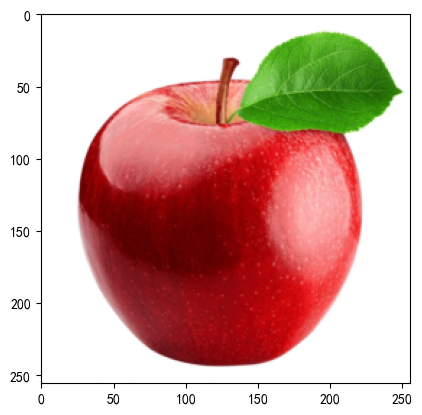

In [113]:
#画图
plt.imshow(img_numpy)
plt.show()

In [114]:
#4.加噪音，得到模型输入
img_noise=img_tensor+torch.randn_like(img_tensor)*0.2

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.76999617..1.7869053].


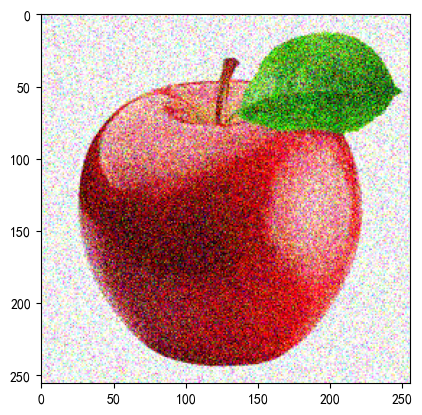

In [115]:
#5.将噪声图片转换为ndarray,画图
img_noise_numpy=img_noise.permute(1,2,0).numpy()
plt.imshow(img_noise_numpy)
plt.show()

### 2.定义模型

In [116]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder,self).__init__()
        #编码器
        self.encode=nn.Sequential(
            nn.Conv2d(3,16,1,1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            nn.Conv2d(16,32,3,1,1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        )
        #解码器
        self.decode=nn.Sequential(
            nn.ConvTranspose2d(in_channels=32,out_channels=16,kernel_size=3,stride=2,padding=1,output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=16,out_channels=3,kernel_size=3,stride=2,padding=1,output_padding=1),
            #输出限制在[0-1]
            nn.Sigmoid(),

        )
    def forward(self,x):
        #编码
        features=self.encode(x)
        # print(features.shape)
        #解码
        output=self.decode(features)
        # print(output.shape)
        return output

In [117]:
model=Autoencoder()
#测试前向传播
input=torch.randn(10,3,256,256)
output=model(input)
print(output.shape)

torch.Size([10, 3, 256, 256])


## 3.模型训练


In [118]:
#定义设备
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)

Autoencoder(
  (encode): Sequential(
    (0): Conv2d(3, 16, kernel_size=(1, 1), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decode): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(16, 3, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
    (3): Sigmoid()
  )
)

In [119]:
#定义超参数
lr=0.001
epoches=1000

In [120]:
#损失函数
loss_fn=nn.MSELoss()
#优化器
optimizer=optim.Adam(model.parameters(),lr=lr)

In [121]:
#训练
for epoch in range(epoches):
    #定义输入和目标值
    input=img_noise.to(device)#添加了噪声的图片,
    target=img_tensor.to(device)#没有添加噪声的图片
    #前向传播
    output=model(input)
    #噪声
    loss=loss_fn(output,target)
    #反向传播
    loss.backward()
    #更新参数
    optimizer.step()
    #梯度清零
    optimizer.zero_grad()

    if(epoch+1)%50==0:
        print(f"Epoch{epoch+1}/{epoches},Loss:{loss.item():.4f}")

Epoch50/1000,Loss:0.0479
Epoch100/1000,Loss:0.0196
Epoch150/1000,Loss:0.0140
Epoch200/1000,Loss:0.0111
Epoch250/1000,Loss:0.0069
Epoch300/1000,Loss:0.0043
Epoch350/1000,Loss:0.0034
Epoch400/1000,Loss:0.0030
Epoch450/1000,Loss:0.0028
Epoch500/1000,Loss:0.0026
Epoch550/1000,Loss:0.0025
Epoch600/1000,Loss:0.0024
Epoch650/1000,Loss:0.0023
Epoch700/1000,Loss:0.0022
Epoch750/1000,Loss:0.0021
Epoch800/1000,Loss:0.0021
Epoch850/1000,Loss:0.0020
Epoch900/1000,Loss:0.0020
Epoch950/1000,Loss:0.0019
Epoch1000/1000,Loss:0.0018


In [122]:
#保存模型
torch.save(model.state_dict(),'model.pt')

## 4.模型推理

In [123]:
#关闭梯度计算
with torch.no_grad():
    #将输入值放到cuda上
    input=img_noise.to(device)
    #得到训练结果
    output=model(input)

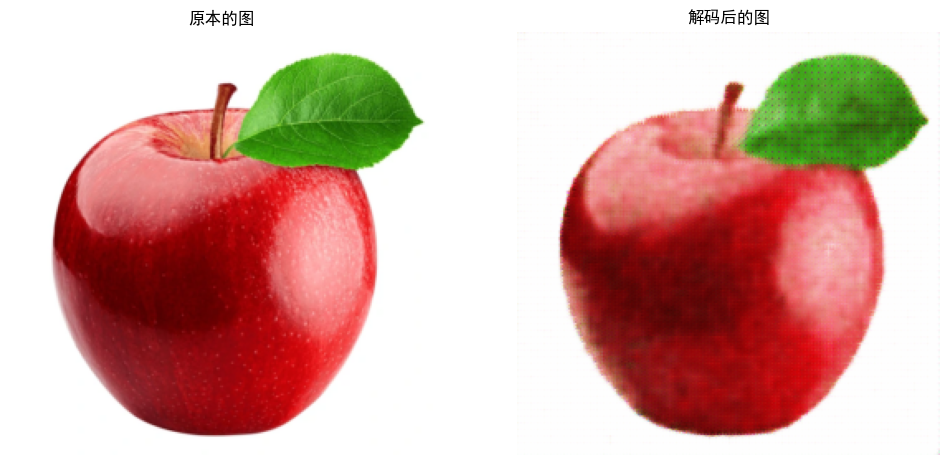

In [126]:
#将训练结果放好cpu上,然后转换维度,再转换为numpy
#  matplotlib画图只能在cpu上,画numpy的图片
img_recon_numpy=output.cpu().permute(1,2,0).numpy()
fig,ax=plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(img_numpy)
ax[0].set_title('原本的图')
ax[0].axis('off')
ax[1].imshow(img_recon_numpy)
ax[1].set_title('解码后的图')
ax[1].axis('off')
plt.show()